In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Cargando perfiles

In [5]:
Family_cte_polarization_LPn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LPn0.npy", allow_pickle=True)
Family_cte_polarization_LNn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn0.npy", allow_pickle=True)
Family_cte_polarization_LNn0_extra = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn0_extra.npy", allow_pickle=True)


In [6]:
len(Family_cte_polarization_LPn0), len(Family_cte_polarization_LNn0)

(57, 64)

(0.0, 15.0)

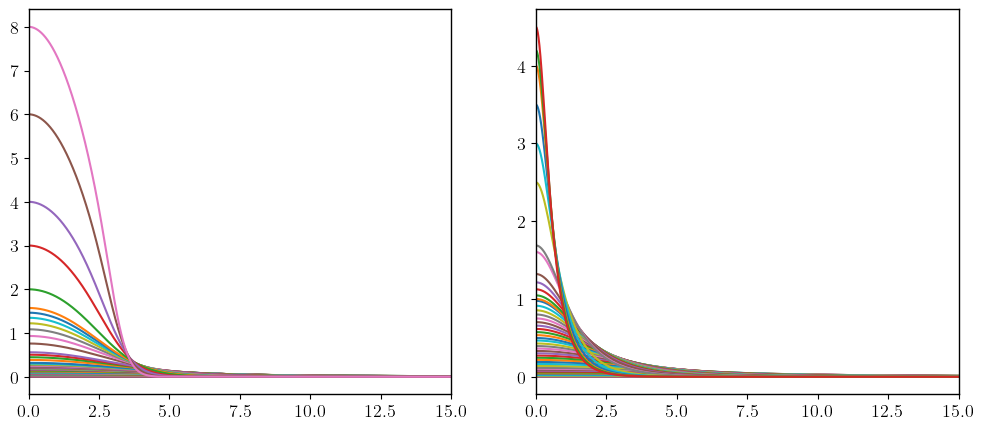

In [7]:
# [Ei, rDnew, sDnew, dsDnew, uDnew, duDnew]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

for dat in Family_cte_polarization_LPn0:
    ax[0].plot(dat[1], dat[2], label=fr"$\sigma_{0}={dat[2][0]:.3f}$")

for dat in Family_cte_polarization_LNn0:
    ax[1].plot(dat[1], dat[2], label=fr"$\sigma_{0}={dat[2][0]:.3f}$")

ax[0].set_xlim(0, 15)
ax[1].set_xlim(0, 15)

### Stability 

In [9]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [8]:
# n = 0
s0 = Family_cte_polarization_LPn0
#s0M = Family_cte_polarization_LNn0
#s0M_ext = Family_cte_polarization_LNn0_extra

In [10]:
lambdaValGeneral, dataExtraGeneral = [[], []], [[], []]
datFuncGeneral = [[], []]

polariz = 'linear'

Jval = [4, 5] # [0, 1, 2, 3]
alp = 0.0
ln = [1.] # 1., -1.
for cont0, conf in enumerate([s0]):  #s0M s0 s0M_ext
    print('#' * 50)
    lamV = [ln[cont0], 0] # ln, ls
    for cont, s in enumerate(conf, start=0): 
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
        print('==> ', sDnew[0])
        datFunc = [
            [interp1d(rDnew, sDnew)],
            [interp1d(rDnew, uDnew)],
        ]

        if cont < 2:
            rMax = 7000
            Nptos = 850
        elif cont < 10:
            rMax = 1200
            Nptos = 700
        else:
            rMax = 800
            Nptos = 600
        print(f"rMax = {rMax}, Nptos = {Nptos}")

        # Graphing
        #rad2 = np.linspace(0, rMax, 500000)
        #fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
        #               sharex=False, sharey=False,
        #               gridspec_kw=dict(hspace=0, wspace=.2))

        #ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))
        #ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
        #ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
        #ax[0].set_xlim(0, rMax)
        #ax[0].set_yscale('log')    
        #plt.show()

        lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    
        for ind, [Jval_temp, data] in enumerate(dataExtra):
            rdis, eingVal, eigVect = data
            print('Jval = %d'%Jval_temp)
            ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
            print(eingVal[ind])

        # Save data
        datFuncGeneral[cont0].append(datFunc)
        lambdaValGeneral[cont0].append(lambdaVal)
        dataExtraGeneral[cont0].append(dataExtra)

##################################################
==>  6.526002112082098e-05
rMax = 7000, Nptos = 850
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.00018157968271111712
rMax = 7000, Nptos = 850
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.0005051772831632206
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.0014050749026625908
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.0039049860578222696
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.010829571686223007
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.032155751120459805
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.03741977259245492
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.04265739468078884
rMax = 1200, Nptos = 700
Jval = 4: [####################] 100%
[]
Jval = 5
[]
==>  0.04

In [11]:
data_real_save = []
for cont, dataExtra in enumerate(dataExtraGeneral[0]):
    temp = datFuncGeneral[0][cont]
    s0Dat = temp[0][0](0)
    dataJ = []
    for ind, [Jval_temp, data] in enumerate(dataExtra):
        rdis, eingVal, eigVect = data
        ind = np.abs(np.real(eingVal)) >= 1e-06 # filtrando los autovalores reales
        dataJ.append([Jval_temp, float(s0Dat), rdis if sum(ind)!=0 else [], eingVal[ind], eigVect[:, ind]])
    data_real_save.append(dataJ)

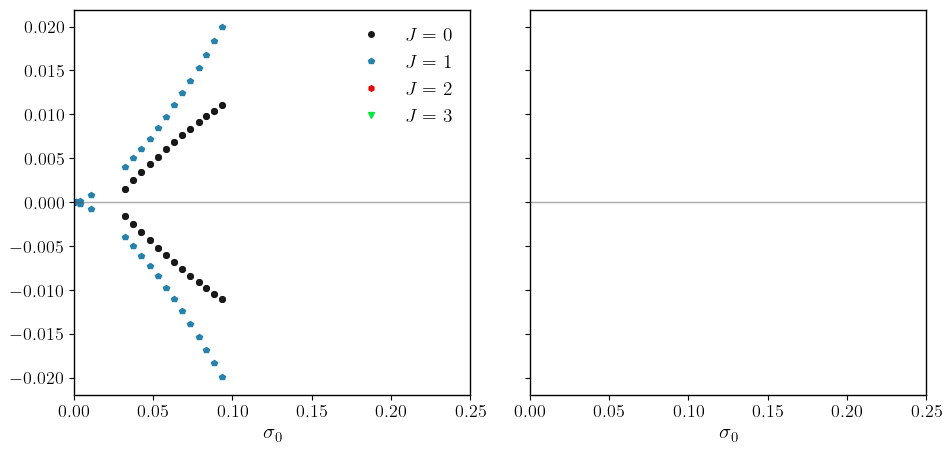

In [18]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 5.), sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0, wspace=.15))

# [Jval_temp, s0, r, eingVal, eigVect]
for cont, dataExtra in enumerate(data_real_save):
      dtemp = []
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            y = eingVal
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if y.size !=0:
                  dtemp.append([x, y])

      ax[0].legend(frameon=False, fontsize=14)
      #ax[0].vlines(x=1, ymin=-1, ymax=1, )


for axes in ax:
    axes.set_xlim(0, .25)
    #axes.set_ylim(-6, 6)
    axes.set_xlabel(r'$\sigma_0$')

    axes.hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

In [6]:
# data_real_save

In [13]:
np.save("Real_Eingevalues_cte_polarization_LNn0", np.array(data_real_save, dtype=object))

In [ ]:
# Plot

In [6]:
# Load the data
Real_Eingevalues_cte_polarization_LNn0 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LNn0.npy", allow_pickle=True)
Real_Eingevalues_cte_polarization_LPn0 = np.load("stability_lambda_n_case/Polarization_constant//Real_Eingevalues_cte_polarization_LPn0.npy", allow_pickle=True)

In [8]:
Real_Eingevalues_cte_polarization_LNn0[0][0]

array([0, 7.105139782470363e-05, list([]), array([], dtype=complex128),
       array([], shape=(4794, 0), dtype=complex128)], dtype=object)

Text(0.15, -5.6, 'stationary (constant), with $\\lambda_n= - 1$ and $\\lambda_s=0$')

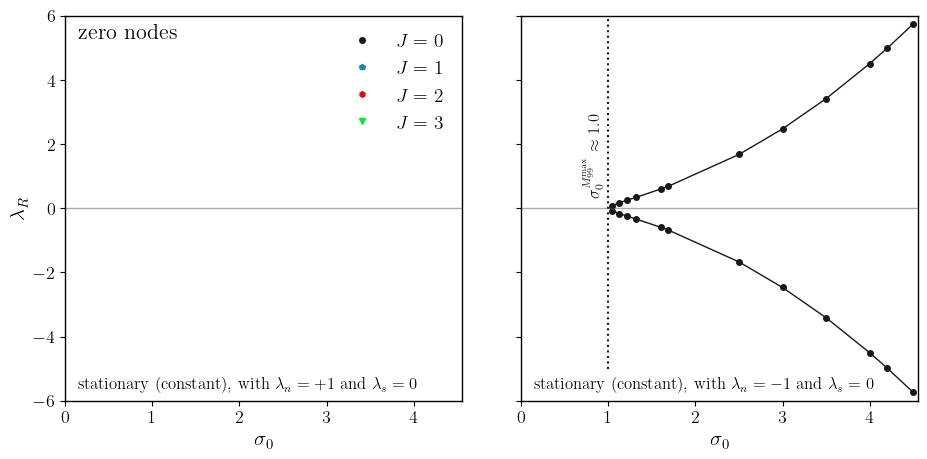

In [78]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 5.), sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0, wspace=.15))

# [Jval_temp, s0, r, eingVal, eigVect]
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn0):
      dtemp = []
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            y = eingVal
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if y.size !=0:
                  dtemp.append([x, y])
      dtemp = np.array(dtemp)
      if dtemp.size !=0:
            ax[0].plot(dtemp[:, 0], dtemp[:,1], ls='--', color=col[cond2])

      ax[0].legend(frameon=False, fontsize=14)
      #ax[0].vlines(x=1, ymin=-1, ymax=1, )

dtemp = []
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if y.size !=0 and cond2==0:
                  dtemp.append([x, y])
dtemp = np.array(dtemp)
if dtemp.size !=0:
      ind = dtemp[:, 1]>0
      ax[1].plot(dtemp[:, 0][ind], dtemp[:, 1][ind], ls='-', color=col[0], lw=1)
      ax[1].plot(dtemp[:, 0][~ind], dtemp[:, 1][~ind], ls='-', color=col[0], lw=1)

ax[1].vlines(x=1.0, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])
ax[1].text(x=0.7, y=0.42, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx1.0$', color=col[0], rotation=90, fontsize=12)

for axes in ax:
    axes.set_xlim(0, 4.55)
    axes.set_ylim(-6, 6)
    axes.set_xlabel(r'$\sigma_0$')

    axes.hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[0].set_ylabel(r'$\lambda_{R}$')

ax[0].text(x=0.15, y=5.3, s=r'zero nodes')
ax[0].text(x=0.15, y=-5.6, s=r'stationary (constant), with $\lambda_n= + 1$ and $\lambda_s=0$', fontsize='12')
ax[1].text(x=0.15, y=-5.6, s=r'stationary (constant), with $\lambda_n= - 1$ and $\lambda_s=0$', fontsize='12')

In [79]:
fig.savefig('stationary_cte_n0.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )

In [7]:
import matplotlib.patches as patches

/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


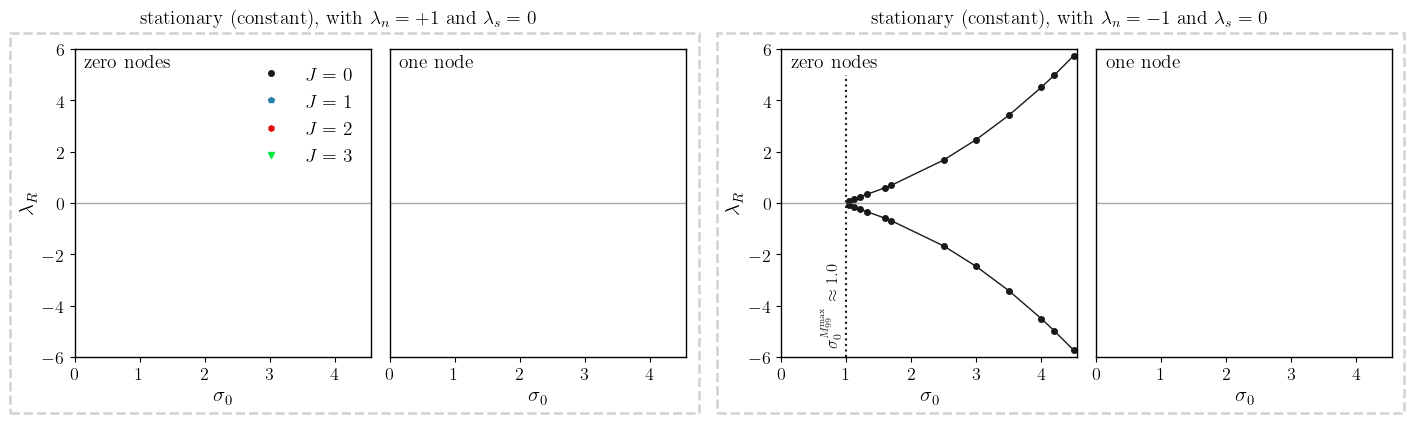

In [8]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

# [Jval_temp, s0, r, eingVal, eigVect]
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn0):
      dtemp = []
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            y = eingVal
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if y.size !=0:
                  dtemp.append([x, y])
      dtemp = np.array(dtemp)
      if dtemp.size !=0:
            ax[0].plot(dtemp[:, 0], dtemp[:,1], ls='--', color=col[cond2])

      ax[0].legend(frameon=False, fontsize=14)
      #ax[0].vlines(x=1, ymin=-1, ymax=1, )

dtemp = []
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if y.size !=0 and cond2==0:
                  dtemp.append([x, y])
dtemp = np.array(dtemp)
if dtemp.size !=0:
      ind = dtemp[:, 1]>0
      ax[2].plot(dtemp[:, 0][ind], dtemp[:, 1][ind], ls='-', color=col[0], lw=1)
      ax[2].plot(dtemp[:, 0][~ind], dtemp[:, 1][~ind], ls='-', color=col[0], lw=1)

ax[2].vlines(x=1.0, ymin=-6, ymax=5, ls=':', lw=1.5, color=col[0])
ax[2].text(x=0.6, y=-5.5, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx1.0$', color=col[0], rotation=90, fontsize=12)

for axes in ax:
    axes.set_xlim(0, 4.55)
    axes.set_ylim(-6, 6)
    axes.set_xlabel(r'$\sigma_0$')

    axes.hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[1].set_yticks([])
ax[3].set_yticks([])
ax[0].set_ylabel(r'$\lambda_{R}$')
ax[2].set_ylabel(r'$\lambda_{R}$')

ax[0].text(x=0.15, y=5.3, s=r'zero nodes', fontsize=14)
ax[2].text(x=0.15, y=5.3, s=r'zero nodes', fontsize=14)
ax[1].text(x=0.15, y=5.3, s=r'one node', fontsize=14)
ax[3].text(x=0.15, y=5.3, s=r'one node', fontsize=14)


# Añadir un marco exterior
rectIzq = patches.Rectangle(
    (0.087, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.405,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,  #'#55555e'
    facecolor="none",
    transform=fig.transFigure,
    zorder=10
)

rectDerec = patches.Rectangle(
    (0.503, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.404,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,
    facecolor='none',
    transform=fig.transFigure,
    zorder=10
)

fig.patches.append(rectIzq)
fig.patches.append(rectDerec)

# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.98,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= + 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

fig.text(
    x=0.71, y=0.98,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= - 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.015, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.015, pos3.y0, pos3.width, pos3.height])


In [191]:
fig.savefig('stationary_cte_lambda.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )